In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import os
print(os.getcwd())

c:\Users\Lutfi\Documents\Project\AITF\rutilahu-vlm\notebooks


In [6]:
# load metadata
with open("../data/mkn_img/house_metadata_split.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total records: {len(data)}")

Total records: 1208


In [7]:
records = []

for rec in data:
    split = rec["split"]
    label = rec["kelayakan_rumah"]
    scheme = rec["dataset_scheme"]

    for img in rec["images"]:
        records.append({
            "split": split,
            "label": label,
            "scheme": scheme,
            "view_type": img["view_type"]
        })

df = pd.DataFrame(records)
df.head()

,split,label,scheme,view_type
0,val,layak,multi,exterior
1,val,layak,multi,interior
2,val,layak,multi,exterior
3,val,layak,multi,interior
4,train,layak,multi,exterior


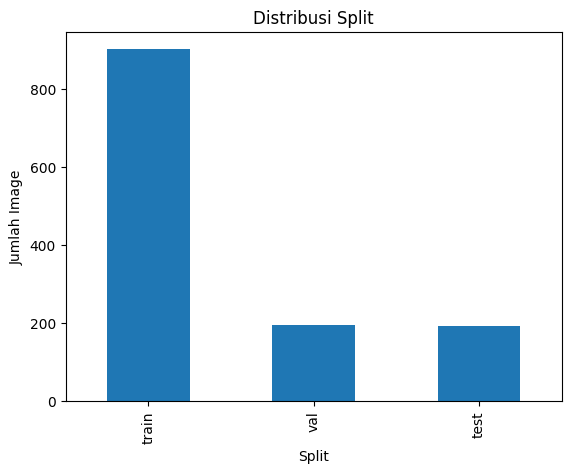

In [8]:
df["split"].value_counts().plot(kind="bar")
plt.title("Distribusi Split")
plt.xlabel("Split")
plt.ylabel("Jumlah Image")
plt.show()

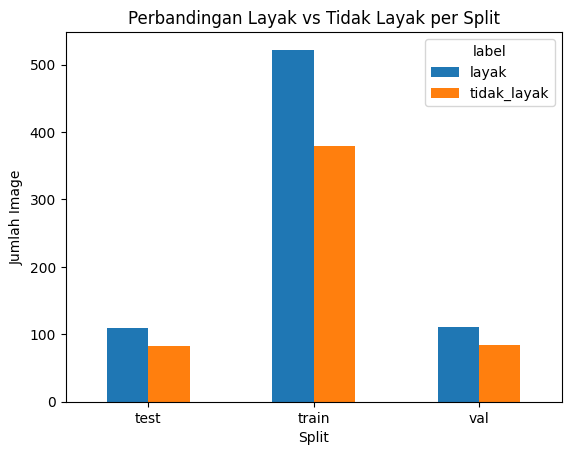

In [9]:
pivot = pd.crosstab(df["split"], df["label"])
pivot.plot(kind="bar")
plt.title("Perbandingan Layak vs Tidak Layak per Split")
plt.xlabel("Split")
plt.ylabel("Jumlah Image")
plt.xticks(rotation=0)
plt.show()

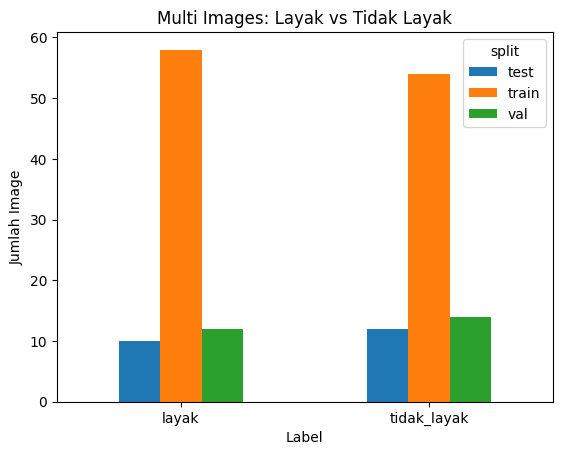

In [10]:
multi_df = df[df["scheme"] == "multi"]

pivot_multi = pd.crosstab(multi_df["label"], multi_df["split"])
pivot_multi.plot(kind="bar")
plt.title("Multi Images: Layak vs Tidak Layak")
plt.xlabel("Label")
plt.ylabel("Jumlah Image")
plt.xticks(rotation=0)
plt.show()

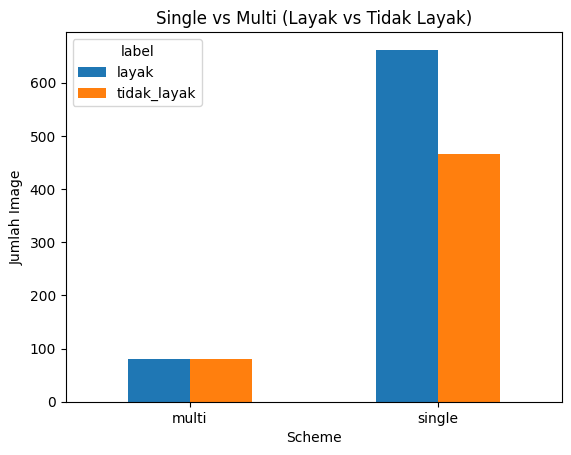

In [11]:
pivot_scheme = pd.crosstab(df["scheme"], df["label"])
pivot_scheme.plot(kind="bar")
plt.title("Single vs Multi (Layak vs Tidak Layak)")
plt.xlabel("Scheme")
plt.ylabel("Jumlah Image")
plt.xticks(rotation=0)
plt.show()

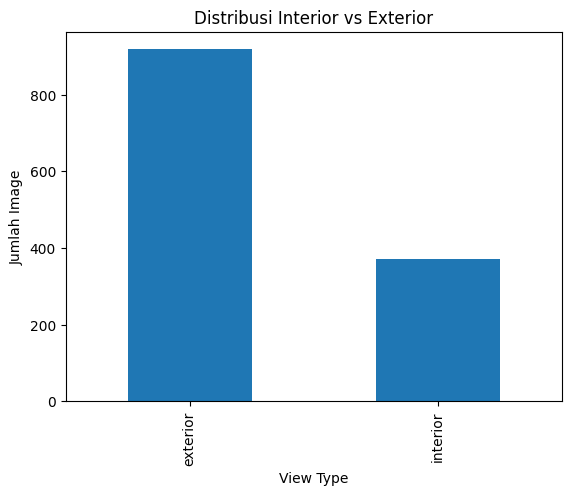

In [12]:
df["view_type"].value_counts().plot(kind="bar")
plt.title("Distribusi Interior vs Exterior")
plt.xlabel("View Type")
plt.ylabel("Jumlah Image")
plt.show()

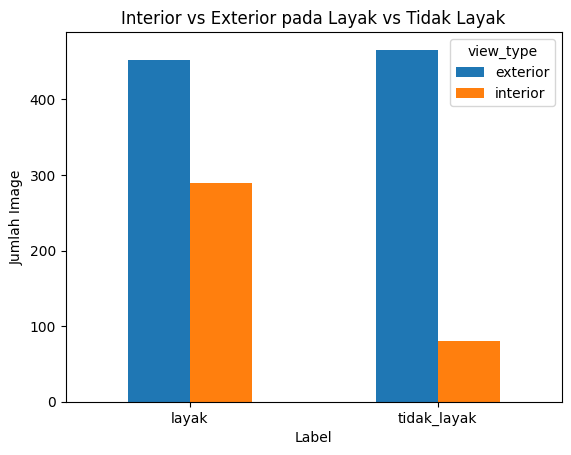

In [13]:
pivot_view = pd.crosstab(df["label"], df["view_type"])
pivot_view.plot(kind="bar")
plt.title("Interior vs Exterior pada Layak vs Tidak Layak")
plt.xlabel("Label")
plt.ylabel("Jumlah Image")
plt.xticks(rotation=0)
plt.show()

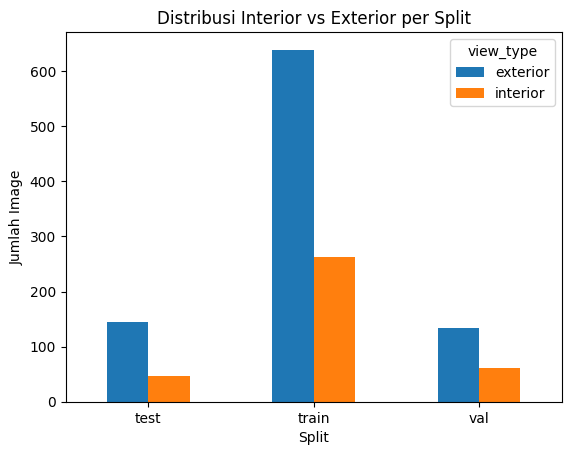

In [14]:
pivot_split_view = pd.crosstab(df["split"], df["view_type"])
pivot_split_view.plot(kind="bar")
plt.title("Distribusi Interior vs Exterior per Split")
plt.xlabel("Split")
plt.ylabel("Jumlah Image")
plt.xticks(rotation=0)
plt.show()

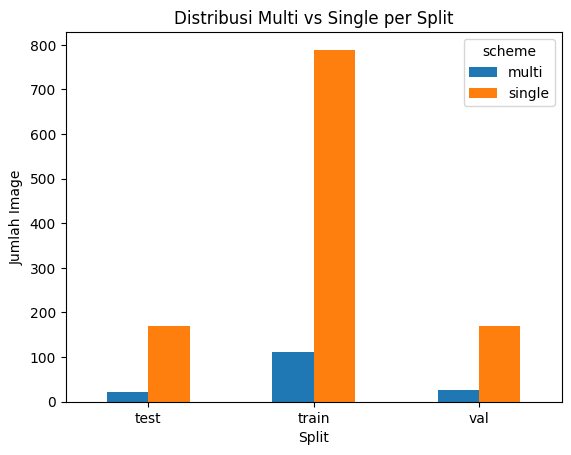

In [15]:
pivot_scheme_split = pd.crosstab(df["split"], df["scheme"])
pivot_scheme_split.plot(kind="bar")
plt.title("Distribusi Multi vs Single per Split")
plt.xlabel("Split")
plt.ylabel("Jumlah Image")
plt.xticks(rotation=0)
plt.show()

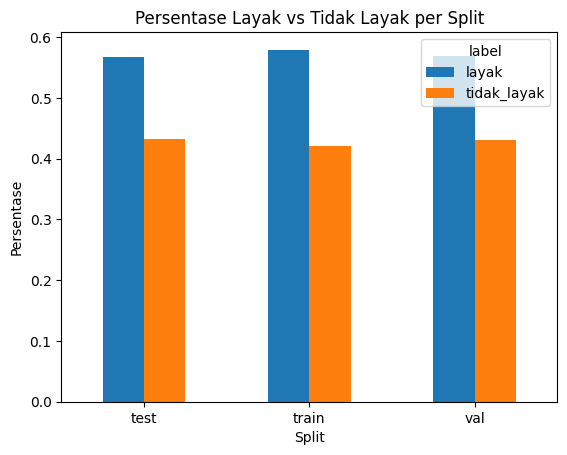

In [16]:
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0)
pivot_percent.plot(kind="bar")
plt.title("Persentase Layak vs Tidak Layak per Split")
plt.xlabel("Split")
plt.ylabel("Persentase")
plt.xticks(rotation=0)
plt.show()